In [174]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
from estimation_forecast_functions import DataCleaner_SGD, BMSM_Forecaster_MLE, GARCH_Forecaster, FIGARCH_Forecaster, pre_whitening, LMSM_Estimator_GMM
from numpy.linalg import solve, inv
from numpy.linalg import cholesky as np_cholesky
from scipy.linalg import toeplitz, solve_triangular
from scipy.stats import chi2 
from scipy.special import polygamma
from autograd import grad
import autograd.numpy as anp
import statsmodels.api as sm
import pandas_datareader.data as web
import datetime as dt
import numdifftools as nd
from statsmodels.tsa.vector_ar.var_model import VAR
from covariance import pwrc_long_run_cov
import yfinance as yf
import numba as nb
from simple_strat_funcs import Clean_Implied_Vols
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from scipy.linalg import cholesky
import jax
import jax.numpy as jnp
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import RandomizedSearchCV


In [2]:
sgd_usd_5m = pd.read_parquet("SGD_USD_5M.parquet")  
cleaner = DataCleaner_SGD(sgd_usd_5m, start_hr=2, end_hr=18, unit_test=False) # replace US SG holidays when needed
realised_variance = cleaner.clean_data()
daily_log_returns = pd.read_parquet("SGD_USD_Daily_matched.parquet")
N = len(daily_log_returns)

start_date = pd.to_datetime(realised_variance.index.min())
end_date = pd.to_datetime(realised_variance.index.max())
implied_vol_data = pd.read_excel('/Users/alexvillamartin/Documents/MSc Diss/Code/USDSGD_1MO_ATM_D.xlsx')
Data_clean = Clean_Implied_Vols(data=implied_vol_data, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance, 
                                align_df2=daily_log_returns)
implied_vol_data, realised_variance, daily_log_returns = Data_clean.get_clean_data()

implied_vols = implied_vol_data['Mid']
implied_vols /= 100 # we need in decimal like others

train_log_returns = daily_log_returns.iloc[:int(N * 0.5)]
test_log_returns = daily_log_returns.iloc[int(N * 0.5):]
train_realised_variance = realised_variance.iloc[:int(N * 0.5)]
test_realised_variance = realised_variance.iloc[int(N * 0.5):]
initial_params = [1.4, np.std(train_log_returns.values *100)]# m0, sigma_bar
H = 30
D = 10


# Recap BMSM first

In [2]:
sgd_usd_5m = pd.read_parquet("SGD_USD_5M.parquet")  
cleaner = DataCleaner_SGD(sgd_usd_5m, start_hr=2, end_hr=18, unit_test=False) # replace US SG holidays when needed
realised_variance = cleaner.clean_data()
daily_log_returns = pd.read_parquet("SGD_USD_Daily_matched.parquet")
N = len(daily_log_returns)

train_log_returns = daily_log_returns.iloc[:int(N * 0.5)]
test_log_returns = daily_log_returns.iloc[int(N * 0.5):]
test_realised_variance = realised_variance.iloc[int(N * 0.5):]
initial_params = [1.4, np.std(train_log_returns.values *100)]# m0, sigma_bar
H = 20

In [3]:
e_data, _, _ = pre_whitening(daily_log_returns.values.flatten() )
e_train = e_data[:int(N * 0.5)]
e_test = e_data[int(N * 0.5):]

bmsm_forecaster = BMSM_Forecaster_MLE(initial_params, 
                                      e_train, 
                                      e_test, 
                                      test_realised_variance.values.flatten(), 
                                      kbar = 8, 
                                      H=H, 
                                    B = 10,
                                    scale=100, 
                                    b = 2.0, 
                                    gamma_kbar=0.5,
                                    percent_space=True)

norm_mse, norm_mae, R2, realised_vol_H_forecasts, realised_vol_H_true = bmsm_forecaster.compute_forecasts()

Estimated parameters: m0=1.243772e+00, sigma_bar=3.131616e-01
Final log-likelihood: -2.549636e+02


In [6]:
print(f"Normalised MSE: {norm_mse:.5f}, Normalised MAE: {norm_mae:.5f}, R2: {R2:.6f}")

Normalised MSE: 0.57620, Normalised MAE: 0.66663, R2: 0.408222


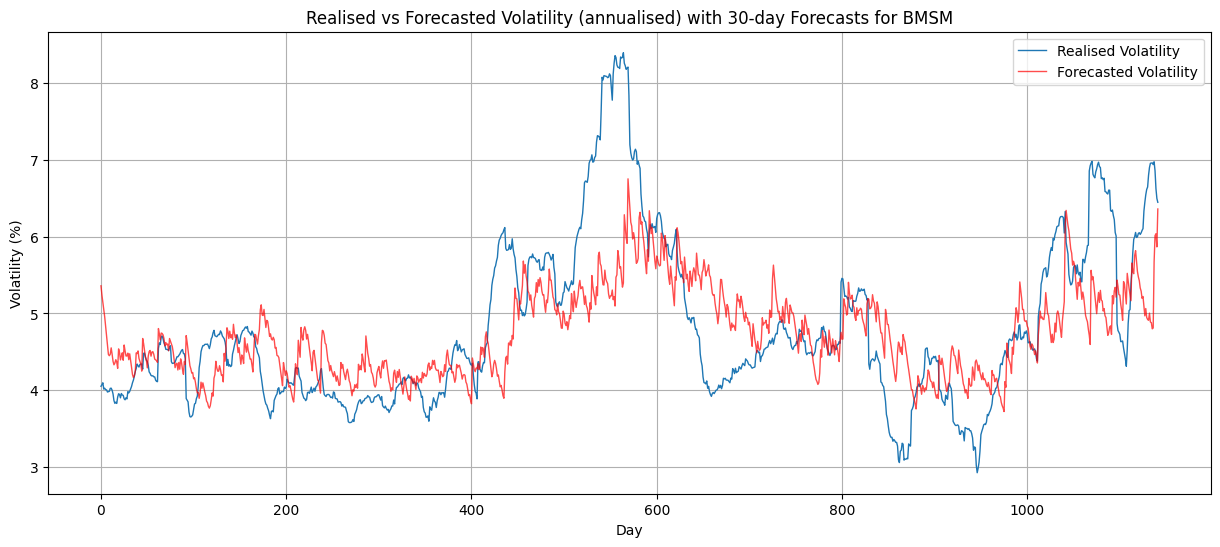

In [43]:
plt.figure(figsize=(15, 6))
plt.plot(realised_vol_H_true, color = 'tab:blue',label='Realised Volatility', linewidth=1)
plt.plot(realised_vol_H_forecasts, color = 'red', label='Forecasted Volatility', linestyle='-', linewidth=1, alpha=0.7)
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.title(f'Realised vs Forecasted Volatility (annualised) with {H}-day Forecasts for BMSM')
plt.grid()
plt.legend()


# SVM-BMSM

In [432]:
class SVM_BMSM_Forecaster_MLE_per_timestep_innovations:

    def __init__(self, 
                  initial_params: list,
                  train_data: np.array, 
                  test_data: np.array,
                  train_realised_variance: np.array,
                  test_realised_variance: np.array,
                  implied_vol: np.array,
                  kbar: int,
                  H: int, 
                  B: int,
                  scale: int = 100, 
                  b: float = 2.0,
                  gamma_kbar: float = 0.5,
                  percent_space: bool = True, 
                  D: int = 30
                  ) -> None:
        '''
        Initialise the MSM forecaster with initial parameters and data.
        Args:
            - initial_params (list): Initial parameters for the MSM model.
            - train_data (np.array): Data to be used for estimating. This is the log returns - not raw, not prices, not as %).
            - test_data (np.array): Data to be used for forecasting. This is the log returns - not raw, not prices, not as %).
            - test_realised_variance (np.array): Realised variance for the test data, used for empirical forecasts.
            - kbar (int): Number of states in the MSM model.
            - H (int): Forecast horizon.
            - B (int): Number of draws for posterior distribution.
            - D (int): Number of days to roll forward for feature computation (ie how many lags of returns or implied vol to use).
        '''
        self.scale = scale
        self.percent_space = percent_space
        if percent_space:
            self.train_data = train_data * self.scale
            self.test_data = test_data * self.scale
            self.test_realised_variance = test_realised_variance * self.scale ** 2
            self.train_realised_variance = train_realised_variance * self.scale ** 2
            self.implied_vol = implied_vol * self.scale
        else:
            self.test_realised_variance = test_realised_variance
            self.train_realised_variance = train_realised_variance
            self.train_data = train_data
            self.test_data = test_data
            self.implied_vol = implied_vol

        self.initial_params = initial_params
        self.kbar = kbar
        self.H = H
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.B = B
        self.D = D

        self.test_size = len(self.test_data) - self.H + 1
        self.predictive_distributions = np.zeros((self.test_size, self.B)) # rows is t and columns is draws - for each row we have B datapoints to compute prob of observing our real forecast

        self.model_params = None
        self.realised_variance_H_forecasts = []
        self.realised_variance_H_true = []
        self.signal_strength = []

        self.optimisation_result = None
        self.cov_theta = None


    def generate_bit_states(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = np.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=np.uint8)

        return bit_states

    def neg_log_likelihood(self, params, bit_states):
        '''
        This function find the negative log likelihood for each return. We do negative as we minimize rather than maximise.
        '''

        m0, sigma_bar, = params

        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])

        m1 = 2 - m0
        states = m0*bit_states + m1*(1 - bit_states)
        A = compute_transition_matrix(states, gamma)

        state_mult = states.prod(axis=1)   # \Pi_{i=1}^k M_{i,t}
        d = states.shape[0] 

        Pi = np.ones(d) / d  
        logL = 0.0

        for r in self.train_data:
            Pi_pred = Pi @ A
            scales = sigma_bar * np.sqrt(state_mult)
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (r / scales) ** 2) 

            pred = np.dot(Pi_pred, density) # inner product
            eps = 1e-300
            logL += np.log(pred + eps)

            numerator = density * Pi_pred # hadamard product
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return - logL
    
        
    def estimate_msm_params(self):

        bit_states = self.generate_bit_states()


        bounds = [(0.001, 1.999), 
                        (1e-6, None)] # m0, sigma_bar
        
        result = minimize(
            self.neg_log_likelihood,
            x0 = self.initial_params,
            args = (bit_states,),
            bounds = bounds,
            method = 'L-BFGS-B', 
            options={
            'disp': True,      
            'iprint': 1})
        
        self.optimisation_result = result
        
        if result.success:
            est = result.x
            print(f"Estimated parameters: m0={est[0]:.6e}, sigma_bar={est[1]:.6e}")
        else:
            raise RuntimeError("MSM estimation failed: " + result.message)
        
        final_logL = -result.fun
        print(f"Final log-likelihood: {final_logL:.6e}")

        self.model_params = np.array([est[0], est[1]]) #m0, sigma_bar

        return result, final_logL
    
    def get_training_innovations(self):
        '''
        Go through training data and compute the H innovations for each time step t.
        '''

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # roll forward D days at the start to get enough returns to compute input feature to our SVR
        for r in range(self.D):
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(self.train_data[r]/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        innovations = np.zeros((len(self.train_data) - self.D - self.H, self.H))
        vol_estimates = np.zeros((len(self.train_data) - self.D - self.H, self.H)) # sigma hat t+i|t for i 1, .., h

        for k in range(self.D, len(self.train_data) - self.H):

            for i in range(1, self.H + 1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)
                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                innovations[k - self.D, i - 1] = (self.train_data[k + i - 1] / np.sqrt(forecast)) ** 2
                vol_estimates[k - self.D, i - 1] = np.sqrt(forecast) 

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.train_data[k] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return innovations, vol_estimates
    
    def get_svr_features(self):
        '''
        Get features given by lagged returns, implied vols and the predicted vol at that specific forecast horizon
        ie for a t+i innovation we have {x_t, .., x_{t-D}, IV_t, ..., IV_{t-D}, vol_t+i|t}

        innovations is (T-D-H, H) so each column corresponds to a SVR.
        '''

        innovations, vol_estimates = self.get_training_innovations()
        n_samples = innovations.shape[0]  
        features = np.zeros((self.H, n_samples, self.D * 2)) 
        
        for i in range(self.H): 
            for t in range(n_samples):  

                current_t = self.D + t
                
                # lagged realised vols for the day
                for lag in range(1, self.D+1):
                    if current_t - lag >= 0:
                        features[i, t, lag-1] = self.train_realised_variance[current_t - lag] ** 0.5
                
                # lagged IVs 
                for lag in range(1, self.D+1):
                    if current_t - lag >= 0:
                        features[i, t, self.D + lag-1] = self.implied_vol[current_t - lag] / np.sqrt(252) # daily verz
                

        return features, innovations
    
    def build_svr_models(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations = self.get_svr_features()   

        param_grid = {
            "regressor__svr__C":       np.logspace(1, 4, 4),    # [1e2, 1e3, 1e4, 1e5, 1e6]      
            "regressor__svr__epsilon": np.logspace(-10, -4, 7),  # [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  
            "regressor__svr__gamma":   np.logspace(1, 3, 3)}

        n_splits = getattr(self, "cv_splits", 5)
        models = {}
        best_params = {}

        from sklearn.compose import TransformedTargetRegressor

        for i in range(self.H):

            X = features[i]
            y = innovations[:, i]

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf"))
            ])

            ttr = TransformedTargetRegressor(
                regressor=pipe,
                transformer=StandardScaler()
                        )

            tscv = TimeSeriesSplit(n_splits=n_splits)
            gs = GridSearchCV(
                estimator=ttr,
                param_grid=param_grid,
                scoring="neg_mean_absolute_error",
                cv=tscv,
                n_jobs=-1,
                refit=True
            )
            gs.fit(X, y)

            models[i] = gs.best_estimator_      
            best_params[i] = gs.best_params_    

        self.best_params_ = best_params
        return models, features, innovations
    

    def compute_forecasts_svm(self):

        _, _ = self.estimate_msm_params()

        models, _, _ = self.build_svr_models()

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # recompute constants from MLE
        for r in self.train_data:
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(r/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        T = len(self.test_data)
        length_train = len(self.train_data)
        all_realised_var = np.concatenate([self.train_realised_variance, self.test_realised_variance])

        for t in range(T - self.H + 1):

            current_sigma2 = np.zeros(self.H)
            current_x2 = np.zeros(self.H)

            for i in range(1, self.H+1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)

                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult) # dot product
                current_sigma2[i-1] = forecast 

                features = np.zeros((1, self.D * 2)) 
                for lag in range(1, self.D+1):

                    features[0, lag - 1] = all_realised_var[length_train + t - lag] ** 0.5
                    features[0, self.D + lag - 1] = self.implied_vol[length_train + t - lag] / np.sqrt(252) # daily verz


                u2_hat = models[i - 1].predict(features)[0]
                current_x2[i-1] = u2_hat * current_sigma2[i-1]
    
            realised_variance_forecast = np.sum(current_x2)

            self.realised_variance_H_forecasts.append(realised_variance_forecast)
            current_true_realised = np.sum(self.test_realised_variance[t : t+self.H])
            self.realised_variance_H_true.append(current_true_realised)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.test_data[t] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        self.realised_variance_H_true = np.array(self.realised_variance_H_true)
        self.realised_variance_H_forecasts = np.array(self.realised_variance_H_forecasts)

        # compute realised volatility
        realised_vol_H_true = np.sqrt(self.realised_variance_H_true)
        realised_vol_H_forecasts = np.sqrt(self.realised_variance_H_forecasts)

        # annualise
        annualiser = np.sqrt(252 / self.H)
        realised_vol_H_true *= annualiser
        realised_vol_H_forecasts *= annualiser

        mse  = np.mean((realised_vol_H_true - realised_vol_H_forecasts)**2)
        tss  = np.mean((realised_vol_H_true - realised_vol_H_true.mean())**2)
        R2   = 1 - mse/tss

        return mse, R2, realised_vol_H_forecasts, realised_vol_H_true



In [73]:
class SVM_BMSM_Forecaster_MLE_per_timestep_innovations2:

    def __init__(self, 
                  initial_params: list,
                  train_data: np.array, 
                  test_data: np.array,
                  train_realised_variance: np.array,
                  test_realised_variance: np.array,
                  implied_vol: np.array,
                  kbar: int,
                  H: int, 
                  B: int,
                  scale: int = 100, 
                  b: float = 2.0,
                  gamma_kbar: float = 0.5,
                  percent_space: bool = True, 
                  D: int = 30
                  ) -> None:
        '''
        Initialise the MSM forecaster with initial parameters and data.
        Args:
            - initial_params (list): Initial parameters for the MSM model.
            - train_data (np.array): Data to be used for estimating. This is the log returns - not raw, not prices, not as %).
            - test_data (np.array): Data to be used for forecasting. This is the log returns - not raw, not prices, not as %).
            - test_realised_variance (np.array): Realised variance for the test data, used for empirical forecasts.
            - kbar (int): Number of states in the MSM model.
            - H (int): Forecast horizon.
            - B (int): Number of draws for posterior distribution.
            - D (int): Number of days to roll forward for feature computation (ie how many lags of returns or implied vol to use).
        '''
        self.scale = scale
        self.percent_space = percent_space
        if percent_space:
            self.train_data = train_data * self.scale
            self.test_data = test_data * self.scale
            self.test_realised_variance = test_realised_variance * self.scale ** 2
            self.train_realised_variance = train_realised_variance * self.scale ** 2
            self.implied_vol = implied_vol * self.scale
        else:
            self.test_realised_variance = test_realised_variance
            self.train_realised_variance = train_realised_variance
            self.train_data = train_data
            self.test_data = test_data
            self.implied_vol = implied_vol

        self.initial_params = initial_params
        self.kbar = kbar
        self.H = H
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.B = B
        self.D = D

        self.test_size = len(self.test_data) - self.H + 1
        self.predictive_distributions = np.zeros((self.test_size, self.B)) # rows is t and columns is draws - for each row we have B datapoints to compute prob of observing our real forecast

        self.model_params = None
        self.realised_variance_H_forecasts = []
        self.realised_variance_H_true = []
        self.signal_strength = []

        self.optimisation_result = None
        self.cov_theta = None


    def generate_bit_states(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = np.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=np.uint8)

        return bit_states

    def neg_log_likelihood(self, params, bit_states):
        '''
        This function find the negative log likelihood for each return. We do negative as we minimize rather than maximise.
        '''

        m0, sigma_bar, = params

        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])

        m1 = 2 - m0
        states = m0*bit_states + m1*(1 - bit_states)
        A = compute_transition_matrix(states, gamma)

        state_mult = states.prod(axis=1)   # \Pi_{i=1}^k M_{i,t}
        d = states.shape[0] 

        Pi = np.ones(d) / d  
        logL = 0.0

        for r in self.train_data:
            Pi_pred = Pi @ A
            scales = sigma_bar * np.sqrt(state_mult)
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (r / scales) ** 2) 

            pred = np.dot(Pi_pred, density) # inner product
            eps = 1e-300
            logL += np.log(pred + eps)

            numerator = density * Pi_pred # hadamard product
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return - logL
    
        
    def estimate_msm_params(self):

        bit_states = self.generate_bit_states()


        bounds = [(0.001, 1.999), 
                        (1e-6, None)] # m0, sigma_bar
        
        result = minimize(
            self.neg_log_likelihood,
            x0 = self.initial_params,
            args = (bit_states,),
            bounds = bounds,
            method = 'L-BFGS-B', 
            options={
            'disp': True,      
            'iprint': 1})
        
        self.optimisation_result = result
        
        if result.success:
            est = result.x
            print(f"Estimated parameters: m0={est[0]:.6e}, sigma_bar={est[1]:.6e}")
        else:
            raise RuntimeError("MSM estimation failed: " + result.message)
        
        final_logL = -result.fun
        print(f"Final log-likelihood: {final_logL:.6e}")

        self.model_params = np.array([est[0], est[1]]) #m0, sigma_bar

        return result, final_logL
    
    def get_training_innovations(self):
        '''
        Go through training data and compute the H innovations for each time step t.
        '''

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # roll forward D days at the start to get enough returns to compute input feature to our SVR
        for r in range(self.D):
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(self.train_data[r]/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        innovations = np.zeros((len(self.train_data) - self.D - self.H, self.H))
        vol_estimates = np.zeros((len(self.train_data) - self.D - self.H, self.H)) # sigma hat t+i|t for i 1, .., h

        for k in range(self.D, len(self.train_data) - self.H):

            for i in range(1, self.H + 1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)
                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                innovations[k - self.D, i - 1] = (self.train_realised_variance[k + i - 1] / forecast)
                vol_estimates[k - self.D, i - 1] = np.sqrt(forecast) 

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.train_data[k] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return innovations, vol_estimates
    
    def get_svr_features(self):
        '''
        Get features given by lagged returns, implied vols and the predicted vol at that specific forecast horizon
        ie for a t+i innovation we have {x_t, .., x_{t-D}, IV_t, ..., IV_{t-D}, vol_t+i|t}

        innovations is (T-D-H, H) so each column corresponds to a SVR.
        '''

        innovations, vol_estimates = self.get_training_innovations()
        n_samples = innovations.shape[0]  
        features = np.zeros((self.H, n_samples, self.D * 2)) 
        
        for i in range(self.H): 
            for t in range(n_samples):  

                current_t = self.D + t
                
                # lagged realised vols for the day
                for lag in range(1, self.D+1):
                    if current_t - lag >= 0:
                        features[i, t, lag-1] = self.train_realised_variance[current_t - lag] ** 0.5
                
                # lagged IVs 
                for lag in range(1, self.D+1):
                    if current_t - lag >= 0:
                        features[i, t, self.D + lag-1] = self.implied_vol[current_t - lag] / np.sqrt(252) # daily verz
                

        return features, innovations
    
    def build_svr_models(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations = self.get_svr_features()   

        param_grid = {
            "regressor__svr__C":       np.logspace(1, 4, 4),    # [1e2, 1e3, 1e4, 1e5, 1e6]      
            "regressor__svr__epsilon": np.logspace(-10, -4, 7),  # [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  
            "regressor__svr__gamma":   np.logspace(1, 3, 3)}

        n_splits = getattr(self, "cv_splits", 5)
        models = {}
        best_params = {}

        from sklearn.compose import TransformedTargetRegressor

        for i in range(self.H):

            X = features[i]
            y = innovations[:, i]

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf"))
            ])

            ttr = TransformedTargetRegressor(
                regressor=pipe,
                transformer=StandardScaler()
                        )

            tscv = TimeSeriesSplit(n_splits=n_splits)
            gs = GridSearchCV(
                estimator=ttr,
                param_grid=param_grid,
                scoring="neg_mean_absolute_error",
                cv=tscv,
                n_jobs=-1,
                refit=True
            )
            gs.fit(X, y)

            models[i] = gs.best_estimator_      
            best_params[i] = gs.best_params_    

        self.best_params_ = best_params
        return models, features, innovations
    

    def compute_forecasts_svm(self):

        _, _ = self.estimate_msm_params()

        models, _, _ = self.build_svr_models()

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # recompute constants from MLE
        for r in self.train_data:
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(r/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        T = len(self.test_data)
        length_train = len(self.train_data)
        all_realised_var = np.concatenate([self.train_realised_variance, self.test_realised_variance])

        for t in range(T - self.H + 1):

            current_sigma2 = np.zeros(self.H)
            current_x2 = np.zeros(self.H)

            for i in range(1, self.H+1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)

                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult) # dot product
                current_sigma2[i-1] = forecast 

                features = np.zeros((1, self.D * 2)) 
                for lag in range(1, self.D+1):

                    features[0, lag - 1] = all_realised_var[length_train + t - lag] ** 0.5
                    features[0, self.D + lag - 1] = self.implied_vol[length_train + t - lag] / np.sqrt(252) # daily verz


                u2_hat = models[i - 1].predict(features)[0]
                current_x2[i-1] = u2_hat * current_sigma2[i-1]
    
            realised_variance_forecast = np.sum(current_x2)

            self.realised_variance_H_forecasts.append(realised_variance_forecast)
            current_true_realised = np.sum(self.test_realised_variance[t : t+self.H])
            self.realised_variance_H_true.append(current_true_realised)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.test_data[t] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        self.realised_variance_H_true = np.array(self.realised_variance_H_true)
        self.realised_variance_H_forecasts = np.array(self.realised_variance_H_forecasts)

        # compute realised volatility
        realised_vol_H_true = np.sqrt(self.realised_variance_H_true)
        realised_vol_H_forecasts = np.sqrt(self.realised_variance_H_forecasts)

        # annualise
        annualiser = np.sqrt(252 / self.H)
        realised_vol_H_true *= annualiser
        realised_vol_H_forecasts *= annualiser

        mse  = np.mean((realised_vol_H_true - realised_vol_H_forecasts)**2)
        mae  = np.mean(np.abs(realised_vol_H_true - realised_vol_H_forecasts))
        tss  = np.mean((realised_vol_H_true - realised_vol_H_true.mean())**2)
        R2   = 1 - mse/tss

        return models, mse, mae, R2, realised_vol_H_forecasts, realised_vol_H_true



In [ ]:

@nb.njit()
def compute_transition_matrix(states, gamma, p_switch = 0.5):
    '''
    We find the transition matrix that is of size 2^kbar x 2^kbar. 
    - states is array and has shape (d, kbar) where d = 2^kbar
    - gamma is array and length kbar
    '''

    d, kbar = states.shape
    T = np.empty((d, d))

    for i in range(d):
        for j in range(d):
            prob = 1

            for k in range(kbar):
                if states[j, k] == states[i, k]: # ie states at t == states at t-1
                    prob *= (1 - gamma[k]) + gamma[k] * p_switch # prob stays + 0.5 * prob switch but we chose this state again
                else:
                    prob *= gamma[k] * p_switch

            T[i, j] = prob

    return T

class SVM_BMSM_Forecaster_MLE_aggregated_innovation:

    def __init__(self, 
                  initial_params: list,
                  train_data: np.array, 
                  test_data: np.array,
                  train_realised_variance: np.array,
                  test_realised_variance: np.array,
                  implied_vol: np.array,
                  kbar: int,
                  H: int, 
                  B: int,
                  scale: int = 100, 
                  b: float = 2.0,
                  gamma_kbar: float = 0.5,
                  percent_space: bool = True, 
                  D: int = 30
                  ) -> None:
        '''
        Initialise the MSM forecaster with initial parameters and data.
        Args:
            - initial_params (list): Initial parameters for the MSM model.
            - train_data (np.array): Data to be used for estimating. This is the log returns - not raw, not prices, not as %).
            - test_data (np.array): Data to be used for forecasting. This is the log returns - not raw, not prices, not as %).
            - test_realised_variance (np.array): Realised variance for the test data, used for empirical forecasts.
            - kbar (int): Number of states in the MSM model.
            - H (int): Forecast horizon.
            - B (int): Number of draws for posterior distribution.
            - D (int): Number of days to roll forward for feature computation (ie how many lags of returns or implied vol to use).
        '''
        self.scale = scale
        self.percent_space = percent_space
        if percent_space:
            self.train_data = train_data * self.scale
            self.test_data = test_data * self.scale
            self.train_realised_variance = train_realised_variance * self.scale ** 2
            self.test_realised_variance = test_realised_variance * self.scale ** 2
            self.implied_vol = implied_vol * self.scale
        else:
            self.test_realised_variance = test_realised_variance
            self.train_realised_variance = train_realised_variance
            self.train_data = train_data
            self.test_data = test_data
            self.implied_vol = implied_vol

        self.initial_params = initial_params
        self.kbar = kbar
        self.H = H
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.B = B
        self.D = D

        self.test_size = len(self.test_data) - self.H + 1
        self.predictive_distributions = np.zeros((self.test_size, self.B)) # rows is t and columns is draws - for each row we have B datapoints to compute prob of observing our real forecast

        self.model_params = None
        self.realised_variance_H_forecasts = []
        self.realised_variance_H_true = []
        self.signal_strength = []

        self.optimisation_result = None
        self.cov_theta = None


    def generate_bit_states(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = np.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=np.uint8)

        return bit_states

    def neg_log_likelihood(self, params, bit_states):
        '''
        This function find the negative log likelihood for each return. We do negative as we minimize rather than maximise.
        '''

        m0, sigma_bar, = params

        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])

        m1 = 2 - m0
        states = m0*bit_states + m1*(1 - bit_states)
        A = compute_transition_matrix(states, gamma)

        state_mult = states.prod(axis=1)   # \Pi_{i=1}^k M_{i,t}
        d = states.shape[0] 

        Pi = np.ones(d) / d  
        logL = 0.0

        for r in self.train_data:
            Pi_pred = Pi @ A
            scales = sigma_bar * np.sqrt(state_mult)
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (r / scales) ** 2) 

            pred = np.dot(Pi_pred, density) # inner product
            eps = 1e-300
            logL += np.log(pred + eps)

            numerator = density * Pi_pred # hadamard product
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return - logL
    
        
    def estimate_msm_params(self):

        bit_states = self.generate_bit_states()


        bounds = [(0.001, 1.999), 
                        (1e-6, None)] # m0, sigma_bar
        
        result = minimize(
            self.neg_log_likelihood,
            x0 = self.initial_params,
            args = (bit_states,),
            bounds = bounds,
            method = 'L-BFGS-B', 
            options={
            'disp': True,      
            'iprint': 1})
        
        self.optimisation_result = result
        
        if result.success:
            est = result.x
            print(f"Estimated parameters: m0={est[0]:.6e}, sigma_bar={est[1]:.6e}")
        else:
            raise RuntimeError("MSM estimation failed: " + result.message)
        
        final_logL = -result.fun
        print(f"Final log-likelihood: {final_logL:.6e}")

        self.model_params = np.array([est[0], est[1]]) #m0, sigma_bar

        return result, final_logL
    
    def get_training_innovations(self):
        '''
        Go through training data and compute the H innovations for each time step t.
        '''

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # roll forward D days at the start to get enough returns to compute input feature to our SVR
        for r in range(self.D):
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(self.train_data[r]/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        innovations = np.zeros((len(self.train_data) - self.D - self.H))
        realised_var_estimates = np.zeros((len(self.train_data) - self.D - self.H)) # sigma hat t+i|t for i 1, .., h
        realised_var_true = np.zeros((len(self.train_data) - self.D - self.H)) # true realised variance for t+i|t

        for k in range(self.D, len(self.train_data) - self.H):

            curr_forecasted_realised_var = 0.0

            for i in range(1, self.H + 1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)
                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                curr_forecasted_realised_var += forecast

            realised_var_estimates[k - self.D] = curr_forecasted_realised_var
            current_true_realised_var = np.sum(self.train_realised_variance[k : k+self.H])
            realised_var_true[k - self.D] = current_true_realised_var

            innovations[k - self.D] = (current_true_realised_var / curr_forecasted_realised_var)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.train_data[k] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return innovations, realised_var_estimates, realised_var_true
    
    def get_svr_features(self):
        '''
        Get features given by lagged returns, implied vols and the predicted vol at that specific forecast horizon
        ie for a t+i innovation we have {x_t, .., x_{t-D}, IV_t, ..., IV_{t-D}, vol_t+i|t}

        innovations is (T-D-H, H) so each column corresponds to a SVR.
        '''

        innovations, realised_var_estimates, realised_var_true = self.get_training_innovations()
        n_samples = innovations.shape[0] 
        features = np.zeros((n_samples, self.D * 2)) 
        
        for t in range(n_samples):  

            current_t = self.D + t
                
            # lagged realised vols
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, lag-1] = self.train_realised_variance[current_t - lag] ** 0.5 # daily so will be available

            # lagged IVs
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, self.D + lag-1] = self.implied_vol[current_t - lag] / np.sqrt(252) # daily verz

        return features, innovations
    
    def build_svr_models(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations = self.get_svr_features()   

        param_grid = {
            "regressor__svr__C":       np.logspace(1, 4, 4),        
            "regressor__svr__epsilon": np.logspace(-14, -6, 9),  
            "regressor__svr__gamma":   np.logspace(1, 3, 4)}

        n_splits = getattr(self, "cv_splits", 5)

        X = features
        y = innovations

        pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf"))])

        ttr = TransformedTargetRegressor(
                regressor=pipe,
                transformer=StandardScaler())

        tscv = TimeSeriesSplit(n_splits=n_splits)
        gs = GridSearchCV(
                estimator=ttr,
                param_grid=param_grid,
                scoring="neg_mean_absolute_error",
                cv=tscv,
                n_jobs=-1,
                refit=True)
        
        gs.fit(X, y)

        models = gs.best_estimator_      
        best_params = gs.best_params_    

        self.best_params_ = best_params
        
        return models, features, innovations
    

    def compute_forecasts_svm(self):

        _, _ = self.estimate_msm_params()

        models, _, _ = self.build_svr_models()

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # recompute constants from MLE
        for r in self.train_data:
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(r/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        T = len(self.test_data)
        length_train = len(self.train_data)
        all_realised_variances = np.concatenate([self.train_realised_variance, self.test_realised_variance])

        for t in range(T - self.H + 1):

            current_realised_var_forecast = 0.0

            for i in range(1, self.H+1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)

                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult) # dot product
                current_realised_var_forecast += forecast
            
            features = np.zeros((1, self.D * 2))
            for lag in range(1, self.D+1):

                features[0, lag - 1] = all_realised_variances[length_train + t - lag] ** 0.5
                features[0, self.D + lag - 1] = self.implied_vol[length_train + t - lag] / np.sqrt(252) # daily verz

            u2_hat = models.predict(features)[0]
            current_realised_var_forecast *= u2_hat

            self.realised_variance_H_forecasts.append(current_realised_var_forecast)
            current_true_realised = np.sum(self.test_realised_variance[t : t+self.H])
            self.realised_variance_H_true.append(current_true_realised)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.test_data[t] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        self.realised_variance_H_true = np.array(self.realised_variance_H_true)
        self.realised_variance_H_forecasts = np.array(self.realised_variance_H_forecasts)

        # compute realised volatility
        realised_vol_H_true = np.sqrt(self.realised_variance_H_true)
        realised_vol_H_forecasts = np.sqrt(self.realised_variance_H_forecasts)

        # annualise
        annualiser = np.sqrt(252 / self.H)
        realised_vol_H_true *= annualiser
        realised_vol_H_forecasts *= annualiser

        mse  = np.mean((realised_vol_H_true - realised_vol_H_forecasts)**2)
        mae = np.mean(np.abs(realised_vol_H_true - realised_vol_H_forecasts))
        tss  = np.mean((realised_vol_H_true - realised_vol_H_true.mean())**2)
        R2   = 1 - mse/tss

        naive_forecast = sigma_bar * np.sqrt(252) 
        naive_mse = np.mean((realised_vol_H_true - naive_forecast)**2)
        naive_mae = np.mean(np.abs(realised_vol_H_true - naive_forecast))

        normalised_mse = mse / naive_mse
        normalised_mae = mae / naive_mae

        return models, normalised_mse, normalised_mae, R2, realised_vol_H_forecasts, realised_vol_H_true



In [98]:

@nb.njit()
def compute_transition_matrix(states, gamma, p_switch = 0.5):
    '''
    We find the transition matrix that is of size 2^kbar x 2^kbar. 
    - states is array and has shape (d, kbar) where d = 2^kbar
    - gamma is array and length kbar
    '''

    d, kbar = states.shape
    T = np.empty((d, d))

    for i in range(d):
        for j in range(d):
            prob = 1

            for k in range(kbar):
                if states[j, k] == states[i, k]: # ie states at t == states at t-1
                    prob *= (1 - gamma[k]) + gamma[k] * p_switch # prob stays + 0.5 * prob switch but we chose this state again
                else:
                    prob *= gamma[k] * p_switch

            T[i, j] = prob

    return T

def compute_transition_matrix_grad(states, gamma, p_switch=0.5):

    eq = states[None, :, :] == states[:, None, :]        
    stay = (1 - gamma) + gamma * p_switch                 
    switch = gamma * p_switch                            
    probs = jnp.where(eq, stay, switch)

    return jnp.prod(probs, axis=-1)    

class SVM_BMSM_Forecaster_MLE_aggregated_innovation_with_uncertainty:

    def __init__(self, 
                  initial_params: list,
                  train_data: np.array, 
                  test_data: np.array,
                  train_realised_variance: np.array,
                  test_realised_variance: np.array,
                  implied_vol: np.array,
                  kbar: int,
                  H: int, 
                  B: int,
                  scale: int = 100, 
                  b: float = 2.0,
                  gamma_kbar: float = 0.5,
                  percent_space: bool = True, 
                  D: int = 30
                  ) -> None:
        '''
        Initialise the MSM forecaster with initial parameters and data.
        Args:
            - initial_params (list): Initial parameters for the MSM model.
            - train_data (np.array): Data to be used for estimating. This is the log returns - not raw, not prices, not as %).
            - test_data (np.array): Data to be used for forecasting. This is the log returns - not raw, not prices, not as %).
            - test_realised_variance (np.array): Realised variance for the test data, used for empirical forecasts.
            - kbar (int): Number of states in the MSM model.
            - H (int): Forecast horizon.
            - B (int): Number of draws for posterior distribution.
            - D (int): Number of days to roll forward for feature computation (ie how many lags of returns or implied vol to use).
        '''
        self.scale = scale
        self.percent_space = percent_space
        if percent_space:
            self.train_data = train_data * self.scale
            self.test_data = test_data * self.scale
            self.train_realised_variance = train_realised_variance * self.scale ** 2
            self.test_realised_variance = test_realised_variance * self.scale ** 2
            self.implied_vol = implied_vol * self.scale
        else:
            self.test_realised_variance = test_realised_variance
            self.train_realised_variance = train_realised_variance
            self.train_data = train_data
            self.test_data = test_data
            self.implied_vol = implied_vol

        self.initial_params = initial_params
        self.kbar = kbar
        self.H = H
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.B = B
        self.D = D

        self.test_size = len(self.test_data) - self.H + 1
        self.predictive_distributions = np.zeros((self.test_size, self.B)) # rows is t and columns is draws - for each row we have B datapoints to compute prob of observing our real forecast

        self.model_params = None
        self.realised_variance_H_forecasts = []
        self.realised_variance_H_true = []
        self.signal_strength = []

        self.optimisation_result = None
        self.cov_theta = None


    def generate_bit_states(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = np.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=np.uint8)

        return bit_states
    
    def generate_bit_states_grad(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = jnp.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=jnp.uint8)

        return bit_states

    def neg_log_likelihood(self, params, bit_states):
        '''
        This function find the negative log likelihood for each return. We do negative as we minimize rather than maximise.
        '''

        m0, sigma_bar, = params

        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])

        m1 = 2 - m0
        states = m0*bit_states + m1*(1 - bit_states)
        A = compute_transition_matrix(states, gamma)

        state_mult = states.prod(axis=1)   # \Pi_{i=1}^k M_{i,t}
        d = states.shape[0] 

        Pi = np.ones(d) / d  
        logL = 0.0

        for r in self.train_data:
            Pi_pred = Pi @ A
            scales = sigma_bar * np.sqrt(state_mult)
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (r / scales) ** 2) 

            pred = np.dot(Pi_pred, density) # inner product
            eps = 1e-300
            logL += np.log(pred + eps)

            numerator = density * Pi_pred # hadamard product
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return - logL
    
        
    def estimate_msm_params(self):

        bit_states = self.generate_bit_states()


        bounds = [(0.001, 1.999), 
                        (1e-6, None)] # m0, sigma_bar
        
        result = minimize(
            self.neg_log_likelihood,
            x0 = self.initial_params,
            args = (bit_states,),
            bounds = bounds,
            method = 'L-BFGS-B', 
            options={
            'disp': True,      
            'iprint': 1})
        
        self.optimisation_result = result
        
        if result.success:
            est = result.x
            print(f"Estimated parameters: m0={est[0]:.6e}, sigma_bar={est[1]:.6e}")
        else:
            raise RuntimeError("MSM estimation failed: " + result.message)
        
        final_logL = -result.fun
        print(f"Final log-likelihood: {final_logL:.6e}")

        self.model_params = np.array([est[0], est[1]]) #m0, sigma_bar

        return result, final_logL
    
    def compute_hessian_and_cov(self):
        '''
        Computes hessian and covariance matrix using numdifftools as value straight from optimiser is not exactly the hessian from forum online.
        '''

        theta_hat = self.model_params
        bit_states = self.generate_bit_states()  

        def nll(theta):
            return self.neg_log_likelihood(theta, bit_states)

        H = nd.Hessian(nll, method='central')(theta_hat)
        H = 0.5 * (H + H.T) # enforce symmetry so PD
        p = H.shape[0]

        try:
            cholesky(H, lower=True) # check PD
        except Exception:
            H = H + (10 * 1e-8) * np.eye(p) # add reg otherwise

        V = inv(H)
        self.cov_theta = V
        
        return H, V
    
    def grad_helper_sigma2(self, theta, curr_Pi):

        m0, sigma_bar = theta
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = jnp.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states_grad()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix_grad(states, gamma)
        state_mult = jnp.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication

        total_variance = 0.0

        for i in range(1, self.H + 1):

                Pi_pred_forecasting = curr_Pi @ jnp.linalg.matrix_power(A, i)
                forecast = jnp.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                total_variance += forecast

        return total_variance


    def get_training_innovations(self):
        '''
        Go through training data and compute the H innovations for each time step t.
        '''

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # roll forward D days at the start to get enough returns to compute input feature to our SVR
        for r in range(self.D):
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(self.train_data[r]/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        innovations = np.zeros((len(self.train_data) - self.D - self.H))
        realised_var_estimates = np.zeros((len(self.train_data) - self.D - self.H)) # sigma hat t+i|t for i 1, .., h
        realised_var_true = np.zeros((len(self.train_data) - self.D - self.H)) # true realised variance for t+i|t
        uncertainty_of_sigma2 = np.zeros((len(self.train_data) - self.D - self.H)) 
        _, Cov = self.compute_hessian_and_cov()

        grad_fn = jax.grad(self.grad_helper_sigma2, argnums = 0)

        for k in range(self.D, len(self.train_data) - self.H):

            curr_forecasted_realised_var = 0.0

            for i in range(1, self.H + 1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)
                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                curr_forecasted_realised_var += forecast

            realised_var_estimates[k - self.D] = curr_forecasted_realised_var
            current_true_realised_var = np.sum(self.train_realised_variance[k : k+self.H])
            realised_var_true[k - self.D] = current_true_realised_var

            innovations[k - self.D] = (current_true_realised_var / curr_forecasted_realised_var)

            theta_jax = jnp.array([m0, sigma_bar])
            Pi_jax = jnp.array(Pi)
            grad_at_k = grad_fn(theta_jax, Pi_jax)
            var_sigma2 = grad_at_k @ Cov @ grad_at_k.T
            uncertainty_of_sigma2[k - self.D] = np.sqrt(var_sigma2)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.train_data[k] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return innovations, realised_var_estimates, realised_var_true, uncertainty_of_sigma2

    def get_svr_features(self):
        '''
        Get features given by lagged returns, implied vols and the predicted vol at that specific forecast horizon
        ie for a t+i innovation we have {x_t, .., x_{t-D}, IV_t, ..., IV_{t-D}, vol_t+i|t}

        innovations is (T-D-H, H) so each column corresponds to a SVR.
        '''

        innovations, realised_var_estimates, realised_var_true, uncertainty_sigma2 = self.get_training_innovations()
        n_samples = innovations.shape[0] 
        features = np.zeros((n_samples, self.D * 2 + 1)) 
        
        for t in range(n_samples):  

            current_t = self.D + t
                
            # lagged realised vols
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, lag-1] = self.train_realised_variance[current_t - lag] ** 0.5 # daily so will be available

            # lagged IVs
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, self.D + lag-1] = self.implied_vol[current_t - lag] / np.sqrt(252) # daily verz

            features[t, self.D * 2] = uncertainty_sigma2[t]

        return features, innovations, uncertainty_sigma2, realised_var_estimates, realised_var_true
    
    def build_svr_models2(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations, uncertainty_of_sigma2, realised_var_estimates, realised_var_true = self.get_svr_features()   

        weights = 1 / (uncertainty_of_sigma2 + 1e-6)  

        param_grid = {
            "regressor__svr__C":       np.logspace(1, 4, 4),        
            "regressor__svr__epsilon": np.logspace(-8, -3, 6),  
            "regressor__svr__gamma":   np.logspace(1, 3, 3)}

        n_splits = getattr(self, "cv_splits", 5)

        X = features
        y = innovations

        pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf"))])

        ttr = TransformedTargetRegressor(
                regressor=pipe,
                transformer=StandardScaler())

        tscv = TimeSeriesSplit(n_splits=n_splits)
        gs = GridSearchCV(
                estimator=ttr,
                param_grid=param_grid,
                scoring="neg_mean_absolute_error",
                cv=tscv,
                n_jobs=-1,
                refit=True)

        gs.fit(X, y, **{"svr__sample_weight": weights})

        models = gs.best_estimator_      
        best_params = gs.best_params_    

        self.best_params_ = best_params
        
        return models, features, innovations
    

    def vol_mse_scorer(self, estimator, X, y, vol):
        '''
        Here vol array is the MSM volatility forecast.
        '''

        u_predict = estimator.predict(X)

        realised_vol_predict = vol * np.sqrt(u_predict)
        realised_vol_true = vol * np.sqrt(y)

        return -mean_squared_error(realised_vol_true, realised_vol_predict)
    

    def build_svr_models(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations, uncertainty_of_sigma2, realised_var_estimates, realised_var_true = self.get_svr_features()   

        features = pd.DataFrame(features)
        innovations = pd.Series(innovations)
        realised_var_estimates = pd.Series(realised_var_estimates)
        uncertainty_of_sigma2 = pd.Series(uncertainty_of_sigma2)

        weights = 1 / (uncertainty_of_sigma2 + 1e-6)  

        param_grid = {
            "regressor__svr__C":       np.logspace(-2, 3, 6),
            "regressor__svr__epsilon": np.logspace(-3, 1, 5),
            "regressor__svr__gamma":   ["scale", "auto", 0.1, 1, 5, 10]
        }

        n_splits = getattr(self, "cv_splits", 5)

        X = features
        y = innovations

        pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf"))])
        
        def inv_log1p_clip(z):
            v = np.expm1(z)        
            return np.maximum(0, v)

        ttr = TransformedTargetRegressor(
                regressor=pipe,
                func = np.log1p, 
                inverse_func = inv_log1p_clip)

        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        def vol_scorer(estimator, X_test, y_test):

            v2_test = realised_var_estimates.loc[X_test.index].values 
            l_pred = estimator.predict(X_test)

            rv2_pred = v2_test * l_pred
            rv2_true = v2_test * y_test
            rv_true = np.sqrt(rv2_true)
            rv_pred = np.sqrt(rv2_pred)
            
            return -mean_squared_error(rv_true, rv_pred)

        gs = GridSearchCV(
                estimator=ttr,
                param_grid=param_grid,
                scoring=vol_scorer,
                cv=tscv,
                n_jobs=-1,
                refit=True)

        gs.fit(X, y, svr__sample_weight = weights)

        models = gs.best_estimator_      
        best_params = gs.best_params_    

        self.best_params_ = best_params
        
        return models, features, innovations
    

    def compute_forecasts_svm(self):

        _, _ = self.estimate_msm_params()

        models, _, _ = self.build_svr_models()

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # recompute constants from MLE
        for r in self.train_data:
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(r/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        T = len(self.test_data)
        length_train = len(self.train_data)
        all_realised_variances = np.concatenate([self.train_realised_variance, self.test_realised_variance])

        _, Cov = self.compute_hessian_and_cov()
        grad_fn = jax.grad(self.grad_helper_sigma2, argnums = 0)

        uncertainty_of_sigma2 = np.zeros((T - self.H + 1))
        innovations = np.zeros((T - self.H + 1))

        for t in range(T - self.H + 1):

            current_realised_var_forecast = 0.0

            for i in range(1, self.H+1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)

                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult) # dot product
                current_realised_var_forecast += forecast

            theta_jax = jnp.array([m0, sigma_bar])
            Pi_jax = jnp.array(Pi)
            grad_at_k = grad_fn(theta_jax, Pi_jax)
            var_sigma2 = grad_at_k @ Cov @ grad_at_k.T
            uncertainty_of_sigma2[t] = np.sqrt(var_sigma2)
            
            features = np.zeros((1, self.D * 2 + 1))
            for lag in range(1, self.D+1):

                features[0, lag - 1] = all_realised_variances[length_train + t - lag] ** 0.5
                features[0, self.D + lag - 1] = self.implied_vol[length_train + t - lag] / np.sqrt(252) # daily verz
            features[0, self.D * 2] = uncertainty_of_sigma2[t]

            u2_hat = models.predict(features)[0]
            innovations[t] = u2_hat
            current_realised_var_forecast *= u2_hat

            self.realised_variance_H_forecasts.append(current_realised_var_forecast)
            current_true_realised = np.sum(self.test_realised_variance[t : t+self.H])
            self.realised_variance_H_true.append(current_true_realised)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.test_data[t] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        self.realised_variance_H_true = np.array(self.realised_variance_H_true)
        self.realised_variance_H_forecasts = np.array(self.realised_variance_H_forecasts)

        # compute realised volatility
        realised_vol_H_true = np.sqrt(self.realised_variance_H_true)
        realised_vol_H_forecasts = np.sqrt(self.realised_variance_H_forecasts)

        # annualise
        annualiser = np.sqrt(252 / self.H)
        realised_vol_H_true *= annualiser
        realised_vol_H_forecasts *= annualiser

        mse  = np.mean((realised_vol_H_true - realised_vol_H_forecasts)**2)
        mae = np.mean(np.abs(realised_vol_H_true - realised_vol_H_forecasts))
        tss  = np.mean((realised_vol_H_true - realised_vol_H_true.mean())**2)
        R2   = 1 - mse/tss

        naive_forecast = sigma_bar * np.sqrt(252) 
        naive_mse = np.mean((realised_vol_H_true - naive_forecast)**2)
        naive_mae = np.mean(np.abs(realised_vol_H_true - naive_forecast))

        normalised_mse = mse / naive_mse
        normalised_mae = mae / naive_mae

        return models, normalised_mse, normalised_mae, R2, realised_vol_H_forecasts, realised_vol_H_true, uncertainty_of_sigma2, innovations



In [194]:

@nb.njit()
def compute_transition_matrix(states, gamma, p_switch = 0.5):
    '''
    We find the transition matrix that is of size 2^kbar x 2^kbar. 
    - states is array and has shape (d, kbar) where d = 2^kbar
    - gamma is array and length kbar
    '''

    d, kbar = states.shape
    T = np.empty((d, d))

    for i in range(d):
        for j in range(d):
            prob = 1

            for k in range(kbar):
                if states[j, k] == states[i, k]: # ie states at t == states at t-1
                    prob *= (1 - gamma[k]) + gamma[k] * p_switch # prob stays + 0.5 * prob switch but we chose this state again
                else:
                    prob *= gamma[k] * p_switch

            T[i, j] = prob

    return T

def compute_transition_matrix_grad(states, gamma, p_switch=0.5):

    eq = states[None, :, :] == states[:, None, :]        
    stay = (1 - gamma) + gamma * p_switch                 
    switch = gamma * p_switch                            
    probs = jnp.where(eq, stay, switch)

    return jnp.prod(probs, axis=-1)    

class SVM_BMSM_Forecaster_MLE_aggregated_innovation_without_uncertainty2:

    def __init__(self, 
                  initial_params: list,
                  train_data: np.array, 
                  test_data: np.array,
                  train_realised_variance: np.array,
                  test_realised_variance: np.array,
                  implied_vol: np.array,
                  kbar: int,
                  H: int, 
                  B: int,
                  scale: int = 100, 
                  b: float = 2.0,
                  gamma_kbar: float = 0.5,
                  percent_space: bool = True, 
                  D: int = 30
                  ) -> None:
        '''
        Initialise the MSM forecaster with initial parameters and data.
        Args:
            - initial_params (list): Initial parameters for the MSM model.
            - train_data (np.array): Data to be used for estimating. This is the log returns - not raw, not prices, not as %).
            - test_data (np.array): Data to be used for forecasting. This is the log returns - not raw, not prices, not as %).
            - test_realised_variance (np.array): Realised variance for the test data, used for empirical forecasts.
            - kbar (int): Number of states in the MSM model.
            - H (int): Forecast horizon.
            - B (int): Number of draws for posterior distribution.
            - D (int): Number of days to roll forward for feature computation (ie how many lags of returns or implied vol to use).
        '''
        self.scale = scale
        self.percent_space = percent_space
        if percent_space:
            self.train_data = train_data * self.scale
            self.test_data = test_data * self.scale
            self.train_realised_variance = train_realised_variance * self.scale ** 2
            self.test_realised_variance = test_realised_variance * self.scale ** 2
            self.implied_vol = implied_vol * self.scale
        else:
            self.test_realised_variance = test_realised_variance
            self.train_realised_variance = train_realised_variance
            self.train_data = train_data
            self.test_data = test_data
            self.implied_vol = implied_vol

        self.initial_params = initial_params
        self.kbar = kbar
        self.H = H
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.B = B
        self.D = D

        self.test_size = len(self.test_data) - self.H + 1
        self.predictive_distributions = np.zeros((self.test_size, self.B)) # rows is t and columns is draws - for each row we have B datapoints to compute prob of observing our real forecast

        self.model_params = None
        self.realised_variance_H_forecasts = []
        self.realised_variance_H_true = []
        self.signal_strength = []

        self.optimisation_result = None
        self.cov_theta = None


    def generate_bit_states(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = np.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=np.uint8)

        return bit_states
    
    def generate_bit_states_grad(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = jnp.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=jnp.uint8)

        return bit_states

    def neg_log_likelihood(self, params, bit_states):
        '''
        This function find the negative log likelihood for each return. We do negative as we minimize rather than maximise.
        '''

        m0, sigma_bar, = params

        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])

        m1 = 2 - m0
        states = m0*bit_states + m1*(1 - bit_states)
        A = compute_transition_matrix(states, gamma)

        state_mult = states.prod(axis=1)   # \Pi_{i=1}^k M_{i,t}
        d = states.shape[0] 

        Pi = np.ones(d) / d  
        logL = 0.0

        for r in self.train_data:
            Pi_pred = Pi @ A
            scales = sigma_bar * np.sqrt(state_mult)
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (r / scales) ** 2) 

            pred = np.dot(Pi_pred, density) # inner product
            eps = 1e-300
            logL += np.log(pred + eps)

            numerator = density * Pi_pred # hadamard product
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return - logL
    
        
    def estimate_msm_params(self):

        bit_states = self.generate_bit_states()


        bounds = [(0.001, 1.999), 
                        (1e-6, None)] # m0, sigma_bar
        
        result = minimize(
            self.neg_log_likelihood,
            x0 = self.initial_params,
            args = (bit_states,),
            bounds = bounds,
            method = 'L-BFGS-B', 
            options={
            'disp': True,      
            'iprint': 1})
        
        self.optimisation_result = result
        
        if result.success:
            est = result.x
            print(f"Estimated parameters: m0={est[0]:.6e}, sigma_bar={est[1]:.6e}")
        else:
            raise RuntimeError("MSM estimation failed: " + result.message)
        
        final_logL = -result.fun
        print(f"Final log-likelihood: {final_logL:.6e}")

        self.model_params = np.array([est[0], est[1]]) #m0, sigma_bar

        return result, final_logL
    

    def get_training_innovations(self):
        '''
        Go through training data and compute the H innovations for each time step t.
        '''

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # roll forward D days at the start to get enough returns to compute input feature to our SVR
        for r in range(self.D):
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(self.train_data[r]/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        innovations = np.zeros((len(self.train_data) - self.D - self.H))
        realised_var_estimates = np.zeros((len(self.train_data) - self.D - self.H)) # sigma hat t+i|t for i 1, .., h
        realised_var_true = np.zeros((len(self.train_data) - self.D - self.H)) # true realised variance for t+i|t

        for k in range(self.D, len(self.train_data) - self.H):

            curr_forecasted_realised_var = 0.0

            for i in range(1, self.H + 1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)
                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                curr_forecasted_realised_var += forecast

            realised_var_estimates[k - self.D] = curr_forecasted_realised_var
            current_true_realised_var = np.sum(self.train_realised_variance[k : k+self.H])
            realised_var_true[k - self.D] = current_true_realised_var

            innovations[k - self.D] = (current_true_realised_var / curr_forecasted_realised_var)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.train_data[k] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return innovations, realised_var_estimates, realised_var_true

    def get_svr_features(self):
        '''
        Get features given by lagged returns, implied vols and the predicted vol at that specific forecast horizon
        ie for a t+i innovation we have {x_t, .., x_{t-D}, IV_t, ..., IV_{t-D}, vol_t+i|t}

        innovations is (T-D-H, H) so each column corresponds to a SVR.
        '''

        innovations, realised_var_estimates, realised_var_true = self.get_training_innovations()
        n_samples = innovations.shape[0] 
        features = np.zeros((n_samples, self.D * 2 + 1)) 
        
        for t in range(n_samples):  

            current_t = self.D + t
                
            # lagged realised vols
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, lag-1] = self.train_realised_variance[current_t - lag] ** 0.5 # daily so will be available

            # lagged IVs
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, self.D + lag-1] = self.implied_vol[current_t - lag] / np.sqrt(252) # daily verz

            features[t, self.D * 2] = realised_var_estimates[t] ** 0.5

        return features, innovations, realised_var_estimates, realised_var_true
    

    def vol_mse_scorer(self, estimator, X, y, vol):
        '''
        Here vol array is the MSM volatility forecast.
        '''

        u_predict = estimator.predict(X)

        realised_vol_predict = vol * np.sqrt(u_predict)
        realised_vol_true = vol * np.sqrt(y)

        return -mean_squared_error(realised_vol_true, realised_vol_predict)
    
    
    def build_svr_models(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations, realised_var_estimates, realised_var_true = self.get_svr_features()   

        features = pd.DataFrame(features)
        innovations = pd.Series(innovations)
        realised_var_estimates = pd.Series(realised_var_estimates)
        
        param_distributions = [
            # RBF only needs C, gamma, epsilon
            {
            "regressor__svr__kernel": ["rbf"],
            "regressor__svr__C":       np.random.uniform(0.1, 50, 100),
            "regressor__svr__epsilon": np.random.uniform(0.01, 1, 100),
            "regressor__svr__gamma":   np.random.uniform(0.01, 10, 100),
            },
            # Polynomial needs degree, coef0, gamma
            {
            "regressor__svr__kernel": ["poly"],
            "regressor__svr__C":       np.random.uniform(0.1, 50, 100),
            "regressor__svr__epsilon": np.random.uniform(0.01, 1, 100),
            "regressor__svr__gamma":   np.random.uniform(0.01, 10, 100),
            "regressor__svr__degree":  np.random.randint(2, 6, 4),
            "regressor__svr__coef0":   np.random.uniform(0.0, 1.0, 100),
            },
            # Sigmoid needs coef0, gamma
            {
            "regressor__svr__kernel": ["sigmoid"],
            "regressor__svr__C":       np.random.uniform(0.1, 50, 100),
            "regressor__svr__epsilon": np.random.uniform(0.01, 1, 100),
            "regressor__svr__gamma":   np.random.uniform(0.01, 10, 100),
            "regressor__svr__coef0":   np.random.uniform(0.0, 1.0, 100),
            }
        ]

        param_grid = {"regressor__svr__kernel": ["poly"],
            "regressor__svr__C":       np.random.uniform(0.1, 50, 100),
            "regressor__svr__epsilon": np.random.uniform(0.01, 1, 100),
            "regressor__svr__gamma":   np.random.uniform(0.01, 10, 100),
            "regressor__svr__degree":  np.random.randint(2, 3, 2),
            "regressor__svr__coef0":   np.random.uniform(0.0, 1.0, 100)
            }                                     


        n_splits = getattr(self, "cv_splits", 4)

        X = features
        y = innovations

        pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR())])
        
        def inv_log1p_clip(z):
            z_clipped = np.minimum(z, 700)
            v = np.expm1(z_clipped)        
            return np.maximum(0, v)

        ttr = TransformedTargetRegressor(
                regressor=pipe,
                func = np.log1p, 
                inverse_func = inv_log1p_clip)

        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        def vol_scorer(estimator, X_test, y_test):

            v2_test = realised_var_estimates.loc[X_test.index].values 
            l_pred = estimator.predict(X_test)

            if not np.all(np.isfinite(l_pred)):
                return -1e9

            rv2_pred = v2_test * l_pred
            rv2_true = v2_test * y_test
            rv_true = np.sqrt(rv2_true)
            rv_pred = np.sqrt(rv2_pred)
            
            return -mean_squared_error(rv_true, rv_pred)

        rs = RandomizedSearchCV(
            estimator=ttr,
            param_distributions=param_grid,
            n_iter=50,                    
            scoring=vol_scorer,
            cv=tscv,
            n_jobs=-1,
            random_state=42,              
            refit=True
        )

        rs.fit(X, y)

        models = rs.best_estimator_      
        best_params = rs.best_params_    

        self.best_params_ = best_params
        
        return models, features, innovations
    

    def compute_forecasts_svm(self):

        _, _ = self.estimate_msm_params()

        models, _, _ = self.build_svr_models()

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # recompute constants from MLE
        for r in self.train_data:
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(r/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        T = len(self.test_data)
        length_train = len(self.train_data)
        all_realised_variances = np.concatenate([self.train_realised_variance, self.test_realised_variance])

        innovations = np.zeros((T - self.H + 1))

        for t in range(T - self.H + 1):

            current_realised_var_forecast = 0.0

            for i in range(1, self.H+1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)

                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult) # dot product
                current_realised_var_forecast += forecast
            
            features = np.zeros((1, self.D * 2 + 1))
            for lag in range(1, self.D+1):

                features[0, lag - 1] = all_realised_variances[length_train + t - lag] ** 0.5
                features[0, self.D + lag - 1] = self.implied_vol[length_train + t - lag] / np.sqrt(252) # daily verz
            features[0, self.D * 2] = current_realised_var_forecast ** 0.5

            u2_hat = models.predict(features)[0]
            innovations[t] = u2_hat
            current_realised_var_forecast *= u2_hat

            self.realised_variance_H_forecasts.append(current_realised_var_forecast)
            current_true_realised = np.sum(self.test_realised_variance[t : t+self.H])
            self.realised_variance_H_true.append(current_true_realised)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.test_data[t] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        self.realised_variance_H_true = np.array(self.realised_variance_H_true)
        self.realised_variance_H_forecasts = np.array(self.realised_variance_H_forecasts)

        # compute realised volatility
        realised_vol_H_true = np.sqrt(self.realised_variance_H_true)
        realised_vol_H_forecasts = np.sqrt(self.realised_variance_H_forecasts)

        # annualise
        annualiser = np.sqrt(252 / self.H)
        realised_vol_H_true *= annualiser
        realised_vol_H_forecasts *= annualiser

        mse  = np.mean((realised_vol_H_true - realised_vol_H_forecasts)**2)
        mae = np.mean(np.abs(realised_vol_H_true - realised_vol_H_forecasts))
        tss  = np.mean((realised_vol_H_true - realised_vol_H_true.mean())**2)
        R2   = 1 - mse/tss

        naive_forecast = sigma_bar * np.sqrt(252) 
        naive_mse = np.mean((realised_vol_H_true - naive_forecast)**2)
        naive_mae = np.mean(np.abs(realised_vol_H_true - naive_forecast))

        normalised_mse = mse / naive_mse
        normalised_mae = mae / naive_mae

        return models, normalised_mse, normalised_mae, R2, realised_vol_H_forecasts, realised_vol_H_true, innovations



In [ ]:

@nb.njit()
def compute_transition_matrix(states, gamma, p_switch = 0.5):
    '''
    We find the transition matrix that is of size 2^kbar x 2^kbar. 
    - states is array and has shape (d, kbar) where d = 2^kbar
    - gamma is array and length kbar
    '''

    d, kbar = states.shape
    T = np.empty((d, d))

    for i in range(d):
        for j in range(d):
            prob = 1

            for k in range(kbar):
                if states[j, k] == states[i, k]: # ie states at t == states at t-1
                    prob *= (1 - gamma[k]) + gamma[k] * p_switch # prob stays + 0.5 * prob switch but we chose this state again
                else:
                    prob *= gamma[k] * p_switch

            T[i, j] = prob

    return T

def compute_transition_matrix_grad(states, gamma, p_switch=0.5):

    eq = states[None, :, :] == states[:, None, :]        
    stay = (1 - gamma) + gamma * p_switch                 
    switch = gamma * p_switch                            
    probs = jnp.where(eq, stay, switch)

    return jnp.prod(probs, axis=-1)    

class SVM_BMSM_Forecaster_MLE_aggregated_innovation_with_uncertainty_u_t:

    def __init__(self, 
                  initial_params: list,
                  train_data: np.array, 
                  test_data: np.array,
                  train_realised_variance: np.array,
                  test_realised_variance: np.array,
                  implied_vol: np.array,
                  kbar: int,
                  H: int, 
                  B: int,
                  scale: int = 100, 
                  b: float = 2.0,
                  gamma_kbar: float = 0.5,
                  percent_space: bool = True, 
                  D: int = 30
                  ) -> None:
        '''
        Initialise the MSM forecaster with initial parameters and data.
        Args:
            - initial_params (list): Initial parameters for the MSM model.
            - train_data (np.array): Data to be used for estimating. This is the log returns - not raw, not prices, not as %).
            - test_data (np.array): Data to be used for forecasting. This is the log returns - not raw, not prices, not as %).
            - test_realised_variance (np.array): Realised variance for the test data, used for empirical forecasts.
            - kbar (int): Number of states in the MSM model.
            - H (int): Forecast horizon.
            - B (int): Number of draws for posterior distribution.
            - D (int): Number of days to roll forward for feature computation (ie how many lags of returns or implied vol to use).
        '''
        self.scale = scale
        self.percent_space = percent_space
        if percent_space:
            self.train_data = train_data * self.scale
            self.test_data = test_data * self.scale
            self.train_realised_variance = train_realised_variance * self.scale ** 2
            self.test_realised_variance = test_realised_variance * self.scale ** 2
            self.implied_vol = implied_vol * self.scale
        else:
            self.test_realised_variance = test_realised_variance
            self.train_realised_variance = train_realised_variance
            self.train_data = train_data
            self.test_data = test_data
            self.implied_vol = implied_vol

        self.initial_params = initial_params
        self.kbar = kbar
        self.H = H
        self.b = b
        self.gamma_kbar = gamma_kbar
        self.B = B
        self.D = D

        self.test_size = len(self.test_data) - self.H + 1
        self.predictive_distributions = np.zeros((self.test_size, self.B)) # rows is t and columns is draws - for each row we have B datapoints to compute prob of observing our real forecast

        self.model_params = None
        self.realised_variance_H_forecasts = []
        self.realised_variance_H_true = []
        self.signal_strength = []

        self.optimisation_result = None
        self.cov_theta = None


    def generate_bit_states(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = np.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=np.uint8)

        return bit_states
    
    def generate_bit_states_grad(self):
        '''
        Build all 2^kbar states as tuples of multipliers m0 and m1=2-m0 in binary form so we can multiply by true m0, m1 later in optimisation. 
        This lists all possible combinations and returns an array with shape (2^kbar, kbar). When kbar is 8 we have 2^kbar = 256.
        '''

        bit_states = jnp.array([[(i >> k) & 1 for k in range(self.kbar)]
                       for i in range(1 << self.kbar)], dtype=jnp.uint8)

        return bit_states

    def neg_log_likelihood(self, params, bit_states):
        '''
        This function find the negative log likelihood for each return. We do negative as we minimize rather than maximise.
        '''

        m0, sigma_bar, = params

        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])

        m1 = 2 - m0
        states = m0*bit_states + m1*(1 - bit_states)
        A = compute_transition_matrix(states, gamma)

        state_mult = states.prod(axis=1)   # \Pi_{i=1}^k M_{i,t}
        d = states.shape[0] 

        Pi = np.ones(d) / d  
        logL = 0.0

        for r in self.train_data:
            Pi_pred = Pi @ A
            scales = sigma_bar * np.sqrt(state_mult)
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (r / scales) ** 2) 

            pred = np.dot(Pi_pred, density) # inner product
            eps = 1e-300
            logL += np.log(pred + eps)

            numerator = density * Pi_pred # hadamard product
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return - logL
    
        
    def estimate_msm_params(self):

        bit_states = self.generate_bit_states()


        bounds = [(0.001, 1.999), 
                        (1e-6, None)] # m0, sigma_bar
        
        result = minimize(
            self.neg_log_likelihood,
            x0 = self.initial_params,
            args = (bit_states,),
            bounds = bounds,
            method = 'L-BFGS-B', 
            options={
            'disp': True,      
            'iprint': 1})
        
        self.optimisation_result = result
        
        if result.success:
            est = result.x
            print(f"Estimated parameters: m0={est[0]:.6e}, sigma_bar={est[1]:.6e}")
        else:
            raise RuntimeError("MSM estimation failed: " + result.message)
        
        final_logL = -result.fun
        print(f"Final log-likelihood: {final_logL:.6e}")

        self.model_params = np.array([est[0], est[1]]) #m0, sigma_bar

        return result, final_logL
    
    def compute_hessian_and_cov(self):
        '''
        Computes hessian and covariance matrix using numdifftools as value straight from optimiser is not exactly the hessian from forum online.
        '''

        theta_hat = self.model_params
        bit_states = self.generate_bit_states()  

        def nll(theta):
            return self.neg_log_likelihood(theta, bit_states)

        H = nd.Hessian(nll, method='central')(theta_hat)
        H = 0.5 * (H + H.T) # enforce symmetry so PD
        p = H.shape[0]

        try:
            cholesky(H, lower=True) # check PD
        except Exception:
            H = H + (10 * 1e-8) * np.eye(p) # add reg otherwise

        V = inv(H)
        self.cov_theta = V
        
        return H, V
    
    def grad_helper_sigma2(self, theta, curr_Pi):

        m0, sigma_bar = theta
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = jnp.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states_grad()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix_grad(states, gamma)
        state_mult = jnp.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication

        total_variance = 0.0

        for i in range(1, self.H + 1):

                Pi_pred_forecasting = curr_Pi @ jnp.linalg.matrix_power(A, i)
                forecast = jnp.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                total_variance += forecast

        return total_variance


    def get_training_innovations(self):
        '''
        Go through training data and compute the H innovations for each time step t.
        '''

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # roll forward D days at the start to get enough returns to compute input feature to our SVR
        for r in range(self.D):
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(self.train_data[r]/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        innovations = np.zeros((len(self.train_data) - self.D - self.H))
        vol_estimates = np.zeros((len(self.train_data) - self.D - self.H)) # sigma hat t+i|t for i 1, .., h
        uncertainty_of_sigma2 = np.zeros((len(self.train_data) - self.D - self.H)) 
        _, Cov = self.compute_hessian_and_cov()

        grad_fn = jax.grad(self.grad_helper_sigma2, argnums = 0)

        for k in range(self.D, len(self.train_data) - self.H):

            curr_forecasted_realised_var = 0.0

            for i in range(1, self.H + 1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)
                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult)

                curr_forecasted_realised_var += forecast

            vol_estimates[k - self.D] = np.sqrt(curr_forecasted_realised_var)

            current_true_realised_var = np.sum(self.train_realised_variance[k : k+self.H])
            innovations[k - self.D] = (current_true_realised_var / curr_forecasted_realised_var) ** 0.5

            theta_jax = jnp.array([m0, sigma_bar])
            Pi_jax = jnp.array(Pi)
            grad_at_k = grad_fn(theta_jax, Pi_jax)
            var_sigma2 = grad_at_k @ Cov @ grad_at_k.T
            uncertainty_of_sigma2[k - self.D] = np.sqrt(var_sigma2)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.train_data[k] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        return innovations, vol_estimates, uncertainty_of_sigma2
    
    def get_svr_features(self):
        '''
        Get features given by lagged returns, implied vols and the predicted vol at that specific forecast horizon
        ie for a t+i innovation we have {x_t, .., x_{t-D}, IV_t, ..., IV_{t-D}, vol_t+i|t}

        innovations is (T-D-H, H) so each column corresponds to a SVR.
        '''

        innovations, vol_estimates, uncertainty_sigma2 = self.get_training_innovations()
        n_samples = innovations.shape[0] 
        features = np.zeros((n_samples, self.D * 2 + 1)) 
        
        for t in range(n_samples):  

            current_t = self.D + t
                
            # lagged realised vols
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, lag-1] = self.train_realised_variance[current_t - lag] ** 0.5 # daily so will be available

            # lagged IVs
            for lag in range(1, self.D+1):
                if current_t - lag >= 0:
                    features[t, self.D + lag-1] = self.implied_vol[current_t - lag] / np.sqrt(252) # daily verz

            features[t, self.D * 2] = uncertainty_sigma2[t]

        return features, innovations, uncertainty_sigma2
    
    def build_svr_models(self):
        '''
        This is done for every horizon so we have an innovation each.
        '''

        features, innovations, uncertainty_of_sigma2 = self.get_svr_features()   

        weights = 1 / (uncertainty_of_sigma2 + 1e-6)  

        param_grid = {
            "regressor__svr__C":       np.logspace(1, 4, 4),        
            "regressor__svr__epsilon": np.logspace(-8, -3, 6),  
            "regressor__svr__gamma":   np.logspace(1, 3, 3)}

        n_splits = getattr(self, "cv_splits", 5)

        X = features
        y = innovations

        pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf"))])

        ttr = TransformedTargetRegressor(
                regressor=pipe,
                transformer=StandardScaler())

        tscv = TimeSeriesSplit(n_splits=n_splits)
        gs = GridSearchCV(
                estimator=ttr,
                param_grid=param_grid,
                scoring="neg_mean_absolute_error",
                cv=tscv,
                n_jobs=-1,
                refit=True)

        gs.fit(X, y, **{"svr__sample_weight": weights})

        models = gs.best_estimator_      
        best_params = gs.best_params_    

        self.best_params_ = best_params
        
        return models, features, innovations
    

    def compute_forecasts_svm(self):

        _, _ = self.estimate_msm_params()

        models, _, _ = self.build_svr_models()

        m0, sigma_bar = self.model_params
        gamma1 = 1 - (1 - self.gamma_kbar)**(1 / self.b**(self.kbar-1))
        gamma = np.array([1 - (1 - gamma1)**(self.b**i) for i in range(self.kbar)])
        states = self.generate_bit_states()

        m1 = 2 - m0
        states = m0 * states + m1 * (1 - states)  
        A = compute_transition_matrix(states, gamma)
        state_mult = np.prod(states, axis=1) # \PI_{i=1}^k M_{i,t} ie multiplication
        d = states.shape[0] 
        Pi = np.ones(d) / d 
        scales = sigma_bar * np.sqrt(state_mult)

        # recompute constants from MLE
        for r in self.train_data:
            Pi_pred = Pi @ A
            density = (1/(np.sqrt(2*np.pi)*scales)) * np.exp(-0.5*(r/scales)**2)
            num = Pi_pred * density
            eps = 1e-300
            den = num.sum() + eps
            Pi = num/den

        T = len(self.test_data)
        length_train = len(self.train_data)
        all_realised_variances = np.concatenate([self.train_realised_variance, self.test_realised_variance])

        _, Cov = self.compute_hessian_and_cov()
        grad_fn = jax.grad(self.grad_helper_sigma2, argnums = 0)

        uncertainty_of_sigma2 = np.zeros((T - self.H + 1))

        for t in range(T - self.H + 1):

            current_realised_var_forecast = 0.0

            for i in range(1, self.H+1):

                Pi_pred_forecasting = Pi @ np.linalg.matrix_power(A, i)

                forecast = np.sum(Pi_pred_forecasting * sigma_bar ** 2 * state_mult) # dot product
                current_realised_var_forecast += forecast

            theta_jax = jnp.array([m0, sigma_bar])
            Pi_jax = jnp.array(Pi)
            grad_at_k = grad_fn(theta_jax, Pi_jax)
            var_sigma2 = grad_at_k @ Cov @ grad_at_k.T
            uncertainty_of_sigma2[t] = np.sqrt(var_sigma2)
            
            features = np.zeros((1, self.D * 2 + 1))
            for lag in range(1, self.D+1):

                features[0, lag - 1] = all_realised_variances[length_train + t - lag] ** 0.5
                features[0, self.D + lag - 1] = self.implied_vol[length_train + t - lag] / np.sqrt(252) # daily verz
            features[0, self.D * 2] = uncertainty_of_sigma2[t]

            u_hat = models.predict(features)[0]

            yy = current_realised_var_forecast ** 0.5
            yy *= u_hat

            self.realised_variance_H_forecasts.append(yy)
            current_true_realised = np.sum(self.test_realised_variance[t : t+self.H])
            self.realised_variance_H_true.append(current_true_realised)

            # update Pi
            density = (1 / (np.sqrt(np.pi * 2) * scales)) * np.exp(- 0.5 * (self.test_data[t] / scales) ** 2)
            Pi_pred = Pi @ A
            numerator = density * Pi_pred # hadamard product
            eps = 1e-300
            denominator = np.sum(numerator) + eps
            Pi = numerator / denominator # bayesian updating

        self.realised_variance_H_true = np.array(self.realised_variance_H_true)
        self.realised_variance_H_forecasts = np.array(self.realised_variance_H_forecasts)

        # compute realised volatility
        realised_vol_H_true = np.sqrt(self.realised_variance_H_true)
        realised_vol_H_forecasts = self.realised_variance_H_forecasts

        # annualise
        annualiser = np.sqrt(252 / self.H)
        realised_vol_H_true *= annualiser
        realised_vol_H_forecasts *= annualiser

        mse  = np.mean((realised_vol_H_true - realised_vol_H_forecasts)**2)
        mae = np.mean(np.abs(realised_vol_H_true - realised_vol_H_forecasts))
        tss  = np.mean((realised_vol_H_true - realised_vol_H_true.mean())**2)
        R2   = 1 - mse/tss

        naive_forecast = sigma_bar * np.sqrt(252) 
        naive_mse = np.mean((realised_vol_H_true - naive_forecast)**2)
        naive_mae = np.mean(np.abs(realised_vol_H_true - naive_forecast))

        normalised_mse = mse / naive_mse
        normalised_mae = mae / naive_mae

        return models, normalised_mse, normalised_mae, R2, realised_vol_H_forecasts, realised_vol_H_true, uncertainty_of_sigma2



In [ ]:
sgd_usd_5m = pd.read_parquet("SGD_USD_5M.parquet")  
cleaner = DataCleaner_SGD(sgd_usd_5m, start_hr=2, end_hr=18, unit_test=False) # replace US SG holidays when needed
realised_variance = cleaner.clean_data()
daily_log_returns = pd.read_parquet("SGD_USD_Daily_matched.parquet")
N = len(daily_log_returns)

start_date = pd.to_datetime(realised_variance.index.min())
end_date = pd.to_datetime(realised_variance.index.max())
implied_vol_data = pd.read_excel('/Users/alexvillamartin/Documents/MSc Diss/Code/USDSGD_1MO_ATM_D.xlsx')
Data_clean = Clean_Implied_Vols(data=implied_vol_data, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance, 
                                align_df2=daily_log_returns)
implied_vol_data, realised_variance, daily_log_returns = Data_clean.get_clean_data()

implied_vols = implied_vol_data['Mid']
implied_vols /= 100 # we need in decimal like others

train_log_returns = daily_log_returns.iloc[:int(N * 0.5)]
test_log_returns = daily_log_returns.iloc[int(N * 0.5):]
train_realised_variance = realised_variance.iloc[:int(N * 0.5)]
test_realised_variance = realised_variance.iloc[int(N * 0.5):]
initial_params = [1.4, np.std(train_log_returns.values *100)]# m0, sigma_bar
H = 30
D = 10

e_data, _, _ = pre_whitening(daily_log_returns.values.flatten())
e_train = e_data[:int(N * 0.5)]
e_test = e_data[int(N * 0.5):]

bmsm_forecaster = SVM_BMSM_Forecaster_MLE_aggregated_innovation_without_uncertainty2(initial_params, 
                                      e_train, 
                                      e_test, 
                                      train_realised_variance.values.flatten(),
                                      test_realised_variance.values.flatten(), 
                                      implied_vol=implied_vols.values.flatten(), 
                                      kbar = 8, 
                                      H=H, 
                                      B = 10,
                                      scale=100, 
                                      b = 2.0, 
                                      gamma_kbar=0.5,
                                      percent_space=True, 
                                      D=D)

models, norm_mse, norm_mae, R2, realised_vol_H_forecasts, realised_vol_H_true, innovations_test = bmsm_forecaster.compute_forecasts_svm()
#res, logL = bmsm_forecaster.estimate_msm_params()
#models, features, innovations = bmsm_forecaster.build_svr_models()
#inn, realised_var_estimates, realised_var_true = bmsm_forecaster.get_training_innovations()

Estimated parameters: m0=1.243772e+00, sigma_bar=3.131616e-01
Final log-likelihood: -2.549636e+02


/opt/homebrew/Cellar/python@3.13/3.13.4/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.4/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.4/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See http

KeyboardInterrupt: 

Below is for uncertainty, var shocks and changed hyperparameter scorer.

In [187]:
print(f"Normalised MSE: {norm_mse:.6f}, Normalised MAE: {norm_mae:.6f}, R2: {R2:.6f}")

Normalised MSE: 20428407226290642891938432063549820830002888707245312039878602003068727125357243411430525825550125357112436693238259912686832898436714202287030121305293238729507885595411030887659748406745842277356407438711790829629924702208033099955852918042851347687122854139617694130955562374424457544440285987153641472.000000, Normalised MAE: 51494236250098140257426863128497402467329903689942472396563063337610096356709695314788952586435405541818547558602538779229569693480446632393747246088192.000000, R2: -20980693558328127497667784478333312490265335435757609459121650225005818757683470488184106491370633653267240840238009016514339513223259312075596820201944190172935969923910856132209259186060809786713567021277660614909846910935169050539916111101172598900085504986749912276364204078459357056992253180014231552.000000


In [188]:
models.get_params

<bound method BaseEstimator.get_params of TransformedTargetRegressor(func=<ufunc 'log1p'>,
                           inverse_func=<function SVM_BMSM_Forecaster_MLE_aggregated_innovation_without_uncertainty2.build_svr_models.<locals>.inv_log1p_clip at 0x168726480>,
                           regressor=Pipeline(steps=[('scaler',
                                                      StandardScaler()),
                                                     ('svr',
                                                      SVR(C=np.float64(5.714744414394448),
                                                          coef0=np.float64(0.7195305421400249),
                                                          epsilon=np.float64(0.4803184656579817),
                                                          gamma=np.float64(8.162768668982368),
                                                          kernel='sigmoid'))]))>

Test innovations: [1.01423205e+304 1.01423205e+304 1.03831693e+162 ... 1.01423205e+304
 1.01423205e+304 1.01423205e+304]


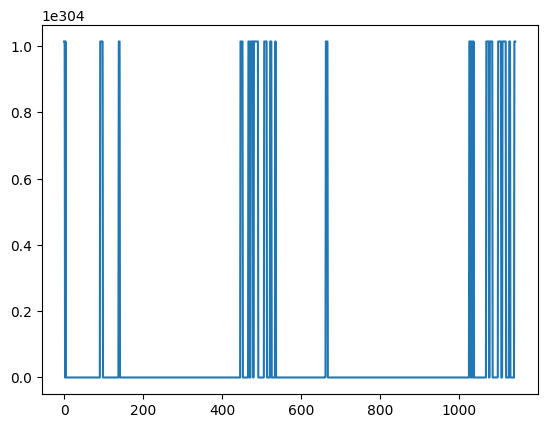

In [189]:
print(f"Test innovations: {innovations_test}")

plt.plot(innovations_test)

Below is for with uncertaininty and modelling var shocks.

In [67]:
print(f"Normalised MSE: {norm_mse:.6f}, Normalised MAE: {norm_mae:.6f}, R2: {R2:.6f}")

Normalised MSE: 0.571760, Normalised MAE: 0.678057, R2: 0.412782


Test innovations: [0.97940449 0.97126571 0.96019949 ... 0.98528378 0.98535312 0.98528648]


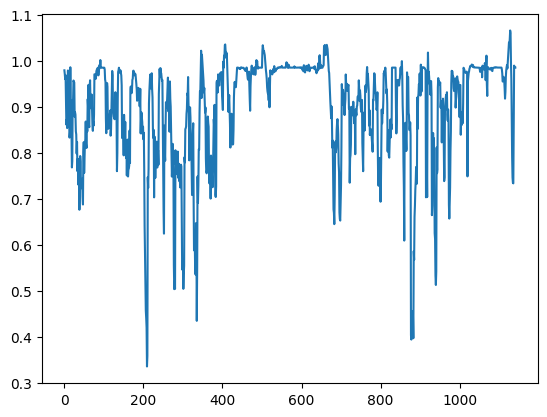

In [82]:
print(f"Test innovations: {innovations_test}")

plt.plot(innovations_test)

Below is for u_t so consider direct volatility shocks and uncertainty. 

In [19]:
print(f"Normalised MSE: {norm_mse:.6f}, Normalised MAE: {norm_mae:.6f}, R2: {R2:.6f}")

Normalised MSE: 0.587554, Normalised MAE: 0.663708, R2: 0.396561


Test correlations with innovations. 

In [37]:
feature_names = [f"lagged_realised_vol_{i}" for i in range(1, D + 1)] + \
                [f"lagged_iv_{i}" for i in range(1, D + 1)] + \
                ["uncertainty_sigma2"]

corrs = np.array([
    np.corrcoef(features[:, i], innovations)[0,1]
    for i in range(features.shape[1])
])
for name, r in zip(feature_names, corrs):
    print(f"{name:20s}  {r:.4f}")

lagged_realised_vol_1  0.2413
lagged_realised_vol_2  0.2305
lagged_realised_vol_3  0.2234
lagged_realised_vol_4  0.2165
lagged_realised_vol_5  0.2090
lagged_realised_vol_6  0.2008
lagged_realised_vol_7  0.1941
lagged_realised_vol_8  0.1900
lagged_realised_vol_9  0.1863
lagged_realised_vol_10  0.1785
lagged_realised_vol_11  0.1689
lagged_realised_vol_12  0.1649
lagged_realised_vol_13  0.1572
lagged_realised_vol_14  0.1554
lagged_realised_vol_15  0.1433
lagged_realised_vol_16  0.1348
lagged_realised_vol_17  0.1282
lagged_realised_vol_18  0.1259
lagged_realised_vol_19  0.1169
lagged_realised_vol_20  0.1173
lagged_realised_vol_21  0.1097
lagged_realised_vol_22  0.1016
lagged_realised_vol_23  0.0874
lagged_realised_vol_24  0.0808
lagged_realised_vol_25  0.0709
lagged_realised_vol_26  0.0676
lagged_realised_vol_27  0.0648
lagged_realised_vol_28  0.0627
lagged_realised_vol_29  0.0622
lagged_realised_vol_30  0.0605
lagged_realised_vol_31  0.0518
lagged_realised_vol_32  0.0450
lagged_realised_v

In [5]:
inn

array([1.03037972, 0.99343993, 1.10352269, ..., 0.99298869, 1.0298701 ,
       1.02052682], shape=(1170,))

In [10]:
x = realised_var_true / realised_var_estimates
x

array([1.03037972, 0.99343993, 1.10352269, ..., 0.99298869, 1.0298701 ,
       1.02052682], shape=(1170,))

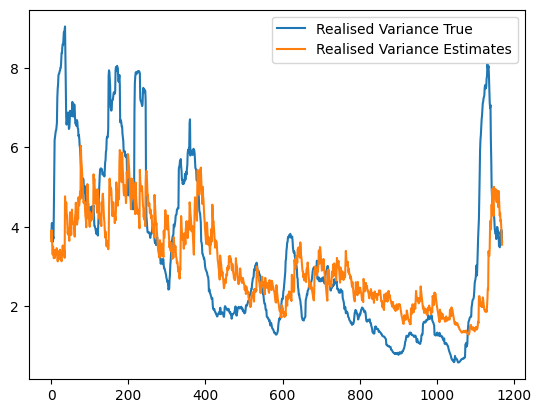

In [7]:
plt.plot(realised_var_true, label='Realised Variance True')
plt.plot(realised_var_estimates, label='Realised Variance Estimates')
plt.legend()

In [16]:
mse, mae, R2

(np.float64(0.674038127447807),
 np.float64(0.6098056453725154),
 np.float64(0.4127821418458245))

In [90]:
models

,regressor,Pipeline(step...at64(10.0)))])
,transformer,StandardScaler()
,func,None
,inverse_func,None
,check_inverse,True
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,np.float64(10.0)


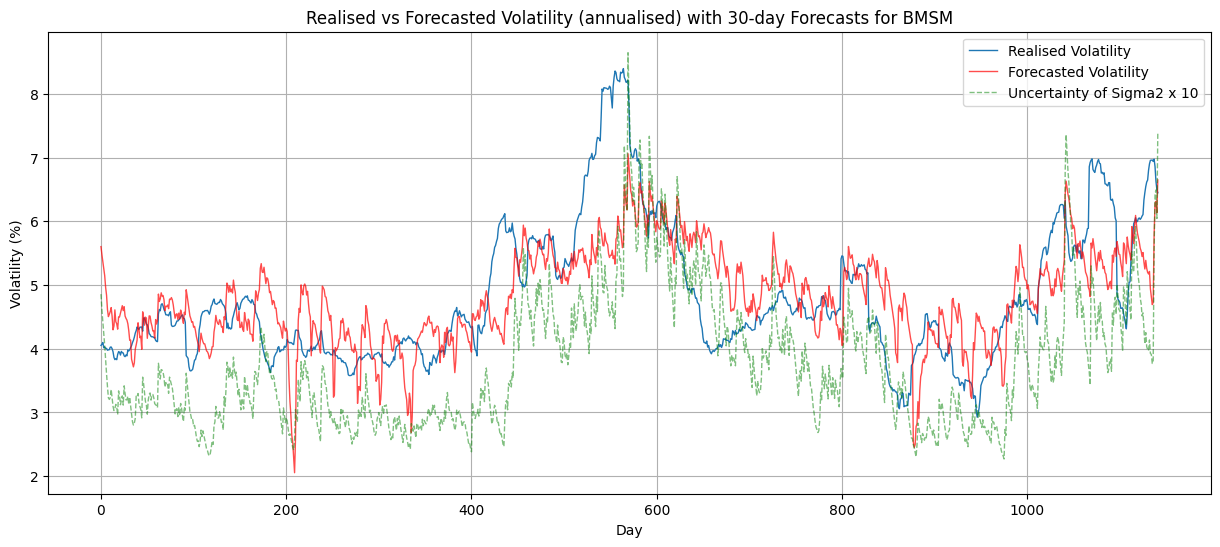

In [181]:
plt.figure(figsize=(15, 6))
plt.plot(realised_vol_H_true, color = 'tab:blue',label='Realised Volatility', linewidth=1)
plt.plot(realised_vol_H_forecasts, color = 'red', label='Forecasted Volatility', linestyle='-', linewidth=1, alpha=0.7)
plt.plot(uncertainty_of_sigma2 * 10, color='green', label='Uncertainty of Sigma2 x 10', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.title(f'Realised vs Forecasted Volatility (annualised) with {H}-day Forecasts for BMSM')
plt.grid()
plt.legend()
